# 05. Model comparison and the value of history data

**Objective.** Compare logistic regression, a random forest and gradient boosting on three feature sets, and test what the external scores and social-circle columns contribute.

**Business question.** Does a more flexible model justify its complexity, and does credit-history data (bureau, previous applications, instalments) improve risk ranking beyond the application form?

**Why this analysis is needed.** This answers the alternate-data question from Phase 1 and selects the model for tuning and calibration in Phase 7. All scores are on the validation split; the test split is untouched.

*Educational project. Not a lending policy.*

## Three models by three feature sets

Feature sets: **application** (raw application columns), **+ratios** (plus the six affordability ratios), **+history** (plus 19 history features).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from src.data import load_modelling_table
from src.plots import apply_style
from src.train import *

warnings.filterwarnings("ignore")
apply_style()
table = load_modelling_table()
y = table[table["split"] == "valid"][config.TARGET].to_numpy()
sets = {
    "application": feature_columns(table),
    "+ratios": feature_columns(table, ratios=True),
    "+history": feature_columns(table, ratios=True, history=True),
}
builders = {
    "logistic": lambda cols: make_logistic(table, cols, log_amounts=True),
    "random forest": lambda cols: make_forest(table, cols),
    "gradient boosting": lambda cols: make_boosting(table, cols),
}
results, predictions = {}, {}
for set_name, cols in sets.items():
    for model_name, build in builders.items():
        scores, probabilities = fit_and_score(build(cols), table, cols)
        results[(model_name, set_name)] = scores
        predictions[(model_name, set_name)] = probabilities
summary = pd.DataFrame(results).T
print(summary[["roc_auc", "pr_auc", "ks", "brier", "mean_predicted", "seconds"]].round(4).to_string())

                               roc_auc  pr_auc      ks   brier  mean_predicted  seconds
logistic          application   0.7467  0.2243  0.3660  0.0687          0.0812  18.6719
random forest     application   0.7398  0.2185  0.3620  0.0695          0.0811  19.2883
gradient boosting application   0.7528  0.2328  0.3782  0.0683          0.0810  18.0979
logistic          +ratios       0.7483  0.2267  0.3706  0.0686          0.0813  15.9802
random forest     +ratios       0.7418  0.2196  0.3663  0.0695          0.0811  20.6165
gradient boosting +ratios       0.7601  0.2383  0.3882  0.0680          0.0808  18.8091
logistic          +history      0.7577  0.2380  0.3865  0.0680          0.0814  18.5940
random forest     +history      0.7490  0.2271  0.3761  0.0691          0.0813  23.9638
gradient boosting +history      0.7690  0.2488  0.4063  0.0675          0.0807  26.8370


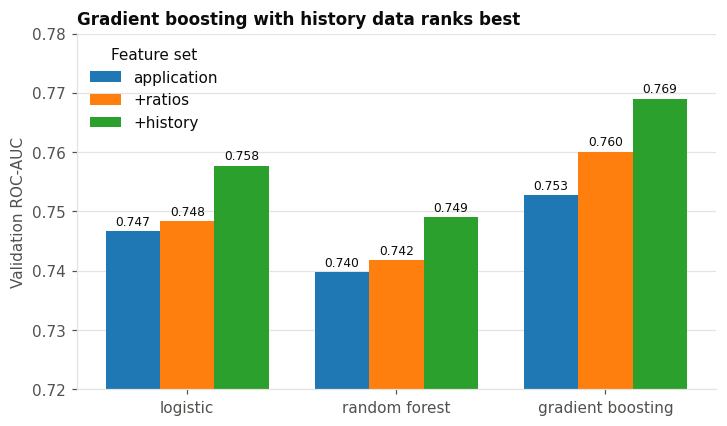

In [2]:
grid = summary["roc_auc"].unstack()[list(sets)].loc[list(builders)]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
width = 0.26
for i, set_name in enumerate(sets):
    bars = ax.bar(np.arange(3) + (i - 1) * width, grid[set_name], width, label=set_name)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001, f"{bar.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(range(3), grid.index)
ax.set_ylim(0.72, 0.78)
ax.set_ylabel("Validation ROC-AUC")
ax.set_title("Gradient boosting with history data ranks best", loc="left")
ax.legend(title="Feature set", frameon=False)
plt.show()

**Result.** ROC-AUC on validation:

| Model | application | +ratios | +history |
|---|---|---|---|
| logistic | 0.7467 | 0.7483 | 0.7577 |
| random forest | 0.7398 | 0.7418 | 0.7490 |
| gradient boosting | 0.7528 | 0.7601 | 0.7690 |

Gradient boosting with everything reaches PR-AUC 0.2488 (three times the random 0.0807), KS 0.406 and Brier 0.0675 (constant-rate 0.0742). Every model's mean predicted probability is within 0.001 of the true 8.07%.

**Interpretation.**
- The random forest is the weakest at every feature set, so it is dropped: it costs more than the logistic model and ranks worse.
- The absolute gains are modest. A well-known ceiling exists for this problem: even the best model here ranks a random defaulter above a random non-defaulter about 77% of the time, not 90%. The application form and history simply do not contain more signal at this level.

## Are the gaps larger than noise?

Differences of one or two thousandths of AUC are within sampling error on 5,000 defaulters. Paired bootstrap (the same resampled rows for both models, 300 resamples) gives an interval for each difference.

In [3]:
rng = np.random.default_rng(config.RANDOM_SEED)
def paired_gap(a, b, repeats=300):
    gaps = []
    for _ in range(repeats):
        rows = rng.integers(0, len(y), len(y))
        gaps.append(roc_auc_score(y[rows], predictions[a][rows]) - roc_auc_score(y[rows], predictions[b][rows]))
    low, high = np.percentile(gaps, [2.5, 97.5])
    return round(float(np.mean(gaps)), 4), round(float(low), 4), round(float(high), 4)

comparisons = {
    "boosting: +ratios vs application": (("gradient boosting", "+ratios"), ("gradient boosting", "application")),
    "boosting: +history vs +ratios": (("gradient boosting", "+history"), ("gradient boosting", "+ratios")),
    "logistic: +history vs +ratios": (("logistic", "+history"), ("logistic", "+ratios")),
    "logistic: +ratios vs application": (("logistic", "+ratios"), ("logistic", "application")),
    "boosting vs logistic, +history": (("gradient boosting", "+history"), ("logistic", "+history")),
    "boosting vs logistic, +ratios": (("gradient boosting", "+ratios"), ("logistic", "+ratios")),
}
gap_table = pd.DataFrame(
    {name: paired_gap(*pair) for name, pair in comparisons.items()}, index=["mean gap", "2.5%", "97.5%"]
).T
print(gap_table.to_string())

                                  mean gap    2.5%   97.5%
boosting: +ratios vs application    0.0072  0.0054  0.0093
boosting: +history vs +ratios       0.0089  0.0062  0.0114
logistic: +history vs +ratios       0.0094  0.0073  0.0118
logistic: +ratios vs application    0.0016  0.0007  0.0026
boosting vs logistic, +history      0.0113  0.0081  0.0145
boosting vs logistic, +ratios       0.0118  0.0091  0.0145


**Result.** For gradient boosting, ratios add +0.0072 AUC (95% interval 0.0054 to 0.0093) and history adds a further +0.0089 (0.0062 to 0.0114). For the logistic model, history adds +0.0094 (0.0073 to 0.0118). Gradient boosting beats logistic regression by +0.0113 (0.0081 to 0.0145) with history and by +0.0118 (0.0091 to 0.0145) without it. Ratios add only +0.0016 (0.0007 to 0.0026) to the logistic model.

**Interpretation.** These intervals exclude zero, so the gains are real, and they are small: the whole ladder from the application form alone to the full model is about 0.016 AUC. The story for an interviewer is honest and specific: history data helps consistently in both model families, boosting helps on top of that, and none of it is dramatic.

## What are the external scores and social-circle columns worth?

`EXT_SOURCE_1-3` are anonymised scores from outside sources; their provenance is unknown. The social-circle counts (how many acquaintances were observed or in default) were flagged in D12 as a possible leakage risk. Each is removed in turn from the full boosting model.

In [4]:
full = sets["+history"]
ablations = {
    "all features": full,
    "without external scores": [c for c in full if c not in EXTERNAL_SCORES],
    "without social circle": [c for c in full if c not in SOCIAL_CIRCLE],
}
rows = {}
for name, cols in ablations.items():
    if name == "all features":
        rows[name] = results[("gradient boosting", "+history")]
        continue
    scores, _ = fit_and_score(make_boosting(table, cols), table, cols)
    rows[name] = scores
print(pd.DataFrame(rows).T[["roc_auc", "pr_auc", "ks", "brier"]].round(4).to_string())

                         roc_auc  pr_auc      ks   brier
all features              0.7690  0.2488  0.4063  0.0675
without external scores   0.7362  0.2076  0.3493  0.0695
without social circle     0.7691  0.2501  0.4039  0.0674


**Result.** Without the external scores ROC-AUC falls from 0.7690 to 0.7362 and PR-AUC from 0.2488 to 0.2076. Without the social-circle columns it is 0.7691: no change.

**Interpretation.**
- The external scores are the most valuable inputs by a wide margin: removing them costs 0.033 AUC, twice the whole gain from ratios and history combined. That has a practical consequence, because a real lender would need to obtain such scores at decision time, and a user of the app cannot type them in. It also means the history features carry real information on their own: with the external scores removed, the history model still reaches 0.7362.
- The social-circle columns add nothing measurable, so there is no reason to keep a column whose meaning and timing are unclear. Dropping them costs nothing and removes the leakage doubt from D12.

## Class weights for the boosting model

The logistic test showed weights damage probabilities without helping ranking. The same test on the full boosting model: balanced weights gave ROC-AUC 0.7682 (vs 0.7690), PR-AUC 0.2503 (vs 0.2488), and mean predicted probability 0.383 against the true 0.081 (Brier 0.1789 vs 0.0675). The small PR-AUC change is inside the noise; the probabilities are unusable. Weights are rejected again.

## Decision

- **Model for Phase 7: gradient boosting on the +history set, without the social-circle columns**, no class weights. It ranks best, and its probabilities are already close to calibrated on average.
- **Logistic regression on the same features stays as the interpretable benchmark** (0.7577), 0.011 AUC behind.
- **Random forest is dropped.**
- **Ratio features are kept** (D18): they add 0.007 AUC for boosting.
- Age and gender (D19) are still in the model; their treatment is deferred to Phase 8.

## Next step

Phase 7: tune the boosting model lightly on the validation split, check calibration (mean prediction is good; the shape across the range is not yet checked), build the threshold and cost analysis, and open the test split once.